<a id="section1"></a>
## 1. Load Libraries and Models

In [1]:
# Import Essential Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pathlib import Path
import joblib
from datetime import datetime

# Machine Learning
from sklearn.preprocessing import RobustScaler, LabelEncoder
import xgboost as xgb

# Configuration
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("✓ All libraries imported successfully!")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")
print(f"XGBoost version: {xgb.__version__}")

✓ All libraries imported successfully!
Pandas version: 2.2.3
NumPy version: 2.1.3
XGBoost version: 3.1.2


In [2]:
# Load trained models
models_dir = Path('models')

if not models_dir.exists():
    print("⚠ ERROR: Models directory not found!")
    print("Please run Notebook 1 first to train and save the models.")
else:
    print("="*80)
    print("LOADING TRAINED MODELS")
    print("="*80)
    
    xgb_model = joblib.load(models_dir / 'xgboost_model.pkl')
    elastic_model = joblib.load(models_dir / 'elastic_net_model.pkl')
    scaler = joblib.load(models_dir / 'scaler.pkl')
    feature_info = joblib.load(models_dir / 'feature_info.pkl')
    model_params = joblib.load(models_dir / 'model_parameters.pkl')
    
    print("✓ XGBoost model loaded")
    print("✓ Elastic Net model loaded")
    print("✓ Scaler loaded")
    print("✓ Feature information loaded")
    
    print(f"\nModel Performance (from training):")
    print(f"  - XGBoost CV RMSE: {model_params['xgb_cv_rmse']}")
    print(f"  - Elastic Net CV RMSE: {model_params['elastic_cv_rmse']}")
    print(f"  - Expected features: {feature_info['n_features']}")

LOADING TRAINED MODELS
✓ XGBoost model loaded
✓ Elastic Net model loaded
✓ Scaler loaded
✓ Feature information loaded

Model Performance (from training):
  - XGBoost CV RMSE: 0.1290 (+/- 0.0161)
  - Elastic Net CV RMSE: 0.1486 (+/- 0.0418)
  - Expected features: 187


<a id="section2"></a>
## 2. Load and Preprocess Test Data

**Note:** The test data must go through the same preprocessing pipeline as the training data.

In [3]:
# Load test data
data_path = Path('./dataset')
test_df = pd.read_csv(data_path / 'test.csv')

print("="*80)
print("TEST DATA LOADED")
print("="*80)
print(f"Test set shape: {test_df.shape}")
print(f"Number of houses to predict: {len(test_df)}")
print(f"\nFirst few rows:")
test_df.head()

TEST DATA LOADED
Test set shape: (1459, 80)
Number of houses to predict: 1459

First few rows:


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Feedr,Norm,1Fam,1Story,5,6,1961,1961,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,CBlock,TA,TA,No,Rec,468.0,LwQ,144.0,270.0,882.0,GasA,TA,Y,SBrkr,896,0,0,896,0.0,0.0,1,0,2,1,TA,5,Typ,0,NaN,Attchd,1961.0,Unf,1.0,730.0,TA,TA,Y,140,0,0,0,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,6,1958,1958,Hip,CompShg,Wd Sdng,Wd Sdng,BrkFace,108.0,TA,TA,CBlock,TA,TA,No,ALQ,923.0,Unf,0.0,406.0,1329.0,GasA,TA,Y,SBrkr,1329,0,0,1329,0.0,0.0,1,1,3,1,Gd,6,Typ,0,NaN,Attchd,1958.0,Unf,1.0,312.0,TA,TA,Y,393,36,0,0,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,5,5,1997,1998,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,PConc,Gd,TA,No,GLQ,791.0,Unf,0.0,137.0,928.0,GasA,Gd,Y,SBrkr,928,701,0,1629,0.0,0.0,2,1,3,1,TA,6,Typ,1,TA,Attchd,1997.0,Fin,2.0,482.0,TA,TA,Y,212,34,0,0,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,6,6,1998,1998,Gable,CompShg,VinylSd,VinylSd,BrkFace,20.0,TA,TA,PConc,TA,TA,No,GLQ,602.0,Unf,0.0,324.0,926.0,GasA,Ex,Y,SBrkr,926,678,0,1604,0.0,0.0,2,1,3,1,Gd,7,Typ,1,Gd,Attchd,1998.0,Fin,2.0,470.0,TA,TA,Y,360,36,0,0,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,Inside,Gtl,StoneBr,Norm,Norm,TwnhsE,1Story,8,5,1992,1992,Gable,CompShg,HdBoard,HdBoard,NaN,0.0,Gd,TA,PConc,Gd,TA,No,ALQ,263.0,Unf,0.0,1017.0,1280.0,GasA,Ex,Y,SBrkr,1280,0,0,1280,0.0,0.0,2,0,2,1,Gd,5,Typ,0,NaN,Attchd,1992.0,RFn,2.0,506.0,TA,TA,Y,0,82,0,0,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal


In [4]:
# Apply the same preprocessing as training data
# (This should match the preprocessing in Notebook 1)

print("="*80)
print("PREPROCESSING TEST DATA")
print("="*80)

test_processed = test_df.copy()

# 1. Missing value treatment
na_means_none = {
    'Alley': 'No_Alley',
    'BsmtQual': 'No_Basement',
    'BsmtCond': 'No_Basement',
    'BsmtExposure': 'No_Basement',
    'BsmtFinType1': 'No_Basement',
    'BsmtFinType2': 'No_Basement',
    'FireplaceQu': 'No_Fireplace',
    'GarageType': 'No_Garage',
    'GarageFinish': 'No_Garage',
    'GarageQual': 'No_Garage',
    'GarageCond': 'No_Garage',
    'PoolQC': 'No_Pool',
    'Fence': 'No_Fence',
    'MiscFeature': 'None',
    'GarageArea': 0,
    'GarageCars': 0,
    'BsmtFinSF1': 0,
    'BsmtFinSF2': 0,
    'BsmtUnfSF': 0,
    'TotalBsmtSF': 0,
    'BsmtFullBath': 0,
    'BsmtHalfBath': 0,
    'MasVnrArea': 0
}

for feature, fill_value in na_means_none.items():
    if feature in test_processed.columns:
        test_processed[feature].fillna(fill_value, inplace=True)

# Special handling for GarageYrBlt
if 'GarageYrBlt' in test_processed.columns and 'YearBuilt' in test_processed.columns:
    test_processed['GarageYrBlt'].fillna(test_processed['YearBuilt'], inplace=True)

# Fill remaining missing values
for col in test_processed.columns:
    if test_processed[col].isnull().sum() > 0:
        if test_processed[col].dtype == 'object':
            test_processed[col].fillna('Unknown', inplace=True)
        else:
            test_processed[col].fillna(test_processed[col].median(), inplace=True)

print(f"✓ Missing values handled: {test_processed.isnull().sum().sum()} remaining")

PREPROCESSING TEST DATA
✓ Missing values handled: 0 remaining


In [5]:
# 2. Categorical encoding
ordinal_features = {
    'ExterQual': ['Po', 'Fa', 'TA', 'Gd', 'Ex'],
    'ExterCond': ['Po', 'Fa', 'TA', 'Gd', 'Ex'],
    'BsmtQual': ['No_Basement', 'Po', 'Fa', 'TA', 'Gd', 'Ex'],
    'BsmtCond': ['No_Basement', 'Po', 'Fa', 'TA', 'Gd', 'Ex'],
    'HeatingQC': ['Po', 'Fa', 'TA', 'Gd', 'Ex'],
    'KitchenQual': ['Po', 'Fa', 'TA', 'Gd', 'Ex'],
    'FireplaceQu': ['No_Fireplace', 'Po', 'Fa', 'TA', 'Gd', 'Ex'],
    'GarageQual': ['No_Garage', 'Po', 'Fa', 'TA', 'Gd', 'Ex'],
    'GarageCond': ['No_Garage', 'Po', 'Fa', 'TA', 'Gd', 'Ex']
}

for feature, categories in ordinal_features.items():
    if feature in test_processed.columns:
        mapping = {cat: idx for idx, cat in enumerate(categories)}
        test_processed[feature] = test_processed[feature].map(mapping)
        test_processed[feature].fillna(-1, inplace=True)

# One-hot encoding
categorical_features = test_processed.select_dtypes(include=['object']).columns.tolist()
if 'Id' in categorical_features:
    categorical_features.remove('Id')

low_cardinality = [col for col in categorical_features if test_processed[col].nunique() < 10]

if low_cardinality:
    test_encoded = pd.get_dummies(test_processed, columns=low_cardinality, drop_first=True)
    test_processed = test_encoded

# Label encoding for high cardinality
high_cardinality = [col for col in test_processed.select_dtypes(include=['object']).columns 
                   if col not in ['Id']]

for col in high_cardinality:
    if col in test_processed.columns:
        le = LabelEncoder()
        test_processed[col] = le.fit_transform(test_processed[col].astype(str))

print(f"✓ Categorical encoding complete")

✓ Categorical encoding complete


In [6]:
# 3. Feature engineering
def engineer_features(df):
    df_eng = df.copy()
    
    if all(col in df_eng.columns for col in ['TotalBsmtSF', '1stFlrSF', '2ndFlrSF']):
        df_eng['TotalSF'] = df_eng['TotalBsmtSF'] + df_eng['1stFlrSF'] + df_eng['2ndFlrSF']
    
    if all(col in df_eng.columns for col in ['BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath']):
        df_eng['TotalBath'] = df_eng['BsmtFullBath'] + 0.5*df_eng['BsmtHalfBath'] + df_eng['FullBath'] + 0.5*df_eng['HalfBath']
    
    if all(col in df_eng.columns for col in ['YrSold', 'YearBuilt']):
        df_eng['HouseAge'] = df_eng['YrSold'] - df_eng['YearBuilt']
        df_eng['HouseAge'] = df_eng['HouseAge'].clip(lower=0)
    
    if all(col in df_eng.columns for col in ['YrSold', 'YearRemodAdd']):
        df_eng['YearsSinceRemodel'] = df_eng['YrSold'] - df_eng['YearRemodAdd']
        df_eng['YearsSinceRemodel'] = df_eng['YearsSinceRemodel'].clip(lower=0)
    
    if all(col in df_eng.columns for col in ['OverallQual', 'TotalSF']):
        df_eng['QualityTimesSize'] = df_eng['OverallQual'] * df_eng['TotalSF']
    
    if all(col in df_eng.columns for col in ['GrLivArea', 'TotRmsAbvGrd']):
        df_eng['AreaPerRoom'] = df_eng['GrLivArea'] / (df_eng['TotRmsAbvGrd'] + 1)
    
    return df_eng

test_engineered = engineer_features(test_processed)
print(f"✓ Feature engineering complete")
print(f"Test data shape: {test_engineered.shape}")

✓ Feature engineering complete
Test data shape: (1459, 170)


In [7]:
# 4. Prepare final feature matrix
X_test_final = test_engineered.drop(['Id'], axis=1, errors='ignore')

# Ensure all columns are numeric
for col in X_test_final.select_dtypes(include=['object']).columns:
    X_test_final[col] = pd.to_numeric(X_test_final[col], errors='coerce').fillna(0)

# Align with training features
expected_features = feature_info['feature_names']

# Add missing features
for feat in expected_features:
    if feat not in X_test_final.columns:
        X_test_final[feat] = 0

# Remove extra features
X_test_final = X_test_final[expected_features]

print("="*80)
print("PREPROCESSING COMPLETE")
print("="*80)
print(f"Final test shape: {X_test_final.shape}")
print(f"Expected features: {len(expected_features)}")
print(f"Match: {'✓ Yes' if X_test_final.shape[1] == len(expected_features) else '✗ No'}")

PREPROCESSING COMPLETE
Final test shape: (1459, 187)
Expected features: 187
Match: ✓ Yes


<a id="section3"></a>
## 3. Generate Predictions

In [8]:
# Generate predictions with all models
print("="*80)
print("GENERATING PREDICTIONS")
print("="*80)

# XGBoost predictions
print("\nPredicting with XGBoost...")
predictions_xgb_log = xgb_model.predict(X_test_final)
predictions_xgb = np.expm1(predictions_xgb_log)  # Convert from log scale
print(f"✓ XGBoost predictions complete")

# Elastic Net predictions (requires scaling)
print("\nPredicting with Elastic Net...")
X_test_scaled = scaler.transform(X_test_final)
predictions_elastic_log = elastic_model.predict(X_test_scaled)
predictions_elastic = np.expm1(predictions_elastic_log)
print(f"✓ Elastic Net predictions complete")

# Ensemble (average of both models)
print("\nCreating ensemble predictions...")
predictions_ensemble = (predictions_xgb + predictions_elastic) / 2
print(f"✓ Ensemble predictions complete")

print(f"\n{'='*80}")
print("PREDICTION SUMMARY")
print("="*80)
print(f"Total predictions: {len(predictions_xgb)}")
print(f"\nXGBoost:")
print(f"  Mean: ${predictions_xgb.mean():,.0f}")
print(f"  Min: ${predictions_xgb.min():,.0f}")
print(f"  Max: ${predictions_xgb.max():,.0f}")
print(f"\nElastic Net:")
print(f"  Mean: ${predictions_elastic.mean():,.0f}")
print(f"  Min: ${predictions_elastic.min():,.0f}")
print(f"  Max: ${predictions_elastic.max():,.0f}")
print(f"\nEnsemble:")
print(f"  Mean: ${predictions_ensemble.mean():,.0f}")
print(f"  Min: ${predictions_ensemble.min():,.0f}")
print(f"  Max: ${predictions_ensemble.max():,.0f}")

GENERATING PREDICTIONS

Predicting with XGBoost...
✓ XGBoost predictions complete

Predicting with Elastic Net...
✓ Elastic Net predictions complete

Creating ensemble predictions...
✓ Ensemble predictions complete

PREDICTION SUMMARY
Total predictions: 1459

XGBoost:
  Mean: $175,701
  Min: $52,241
  Max: $484,009

Elastic Net:
  Mean: $175,737
  Min: $49,926
  Max: $700,510

Ensemble:
  Mean: $175,719
  Min: $51,884
  Max: $495,818


<a id="section4"></a>
## 4. Create Submission Files

In [9]:
# Create submission DataFrames
print("="*80)
print("CREATING SUBMISSION FILES")
print("="*80)

submission_xgb = pd.DataFrame({
    'Id': test_df['Id'],
    'SalePrice': predictions_xgb
})

submission_elastic = pd.DataFrame({
    'Id': test_df['Id'],
    'SalePrice': predictions_elastic
})

submission_ensemble = pd.DataFrame({
    'Id': test_df['Id'],
    'SalePrice': predictions_ensemble
})

# Save to CSV
submission_xgb.to_csv('./dataset/submission_xgboost.csv', index=False)
submission_elastic.to_csv('./dataset/submission_elastic_net.csv', index=False)
submission_ensemble.to_csv('./dataset/submission_ensemble.csv', index=False)

print("✓ Submission files created:")
print("  - submission_xgboost.csv")
print("  - submission_elastic_net.csv")
print("  - submission_ensemble.csv")

# Display sample
print(f"\n{'='*80}")
print("SAMPLE PREDICTIONS (First 10 houses)")
print("="*80)
sample_predictions = pd.DataFrame({
    'Id': test_df['Id'].head(10),
    'XGBoost': predictions_xgb[:10],
    'Elastic_Net': predictions_elastic[:10],
    'Ensemble': predictions_ensemble[:10]
})
print(sample_predictions.to_string(index=False))

CREATING SUBMISSION FILES
✓ Submission files created:
  - submission_xgboost.csv
  - submission_elastic_net.csv
  - submission_ensemble.csv

SAMPLE PREDICTIONS (First 10 houses)
  Id       XGBoost   Elastic_Net      Ensemble
1461 121366.828125 109671.072799 115518.950462
1462 161875.015625 141611.976144 151743.495884
1463 177853.359375 172520.914315 175187.136845
1464 186891.078125 189417.385445 188154.231785
1465 185316.453125 192593.040077 188954.746601
1466 173329.406250 175221.509723 174275.457986
1467 173665.125000 188040.527373 180852.826187
1468 168432.625000 166239.079350 167335.852175
1469 188418.687500 205064.889996 196741.788748
1470 121655.031250 115943.342179 118799.186715


<a id="section5"></a>
## 5. Prediction Analysis

PREDICTION DISTRIBUTION ANALYSIS


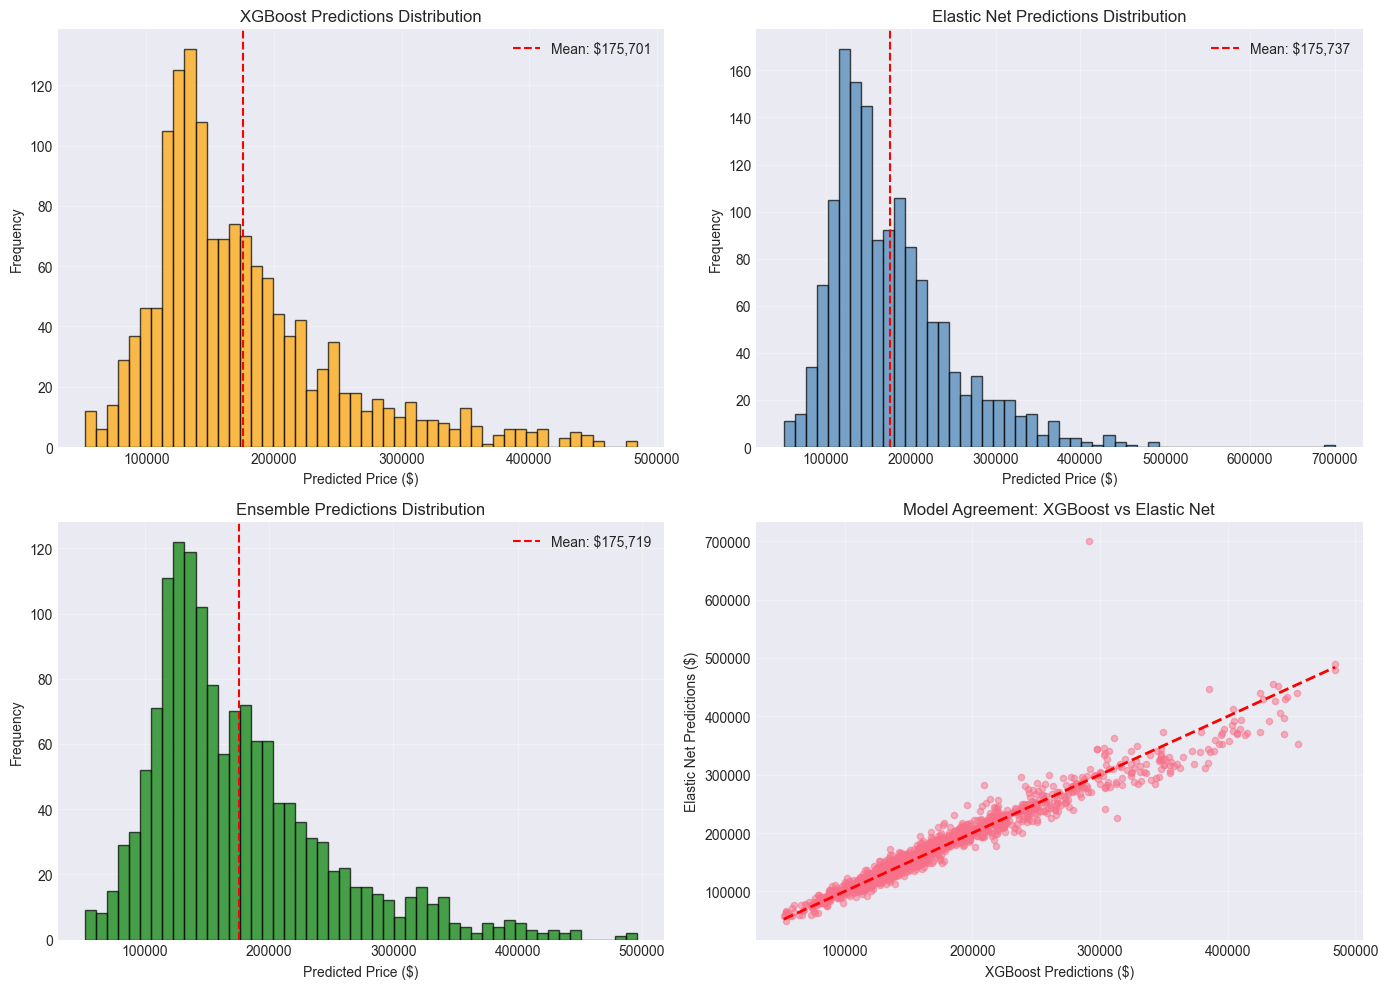


✓ Prediction analysis visualizations complete


In [10]:
# Analyze prediction distribution
print("="*80)
print("PREDICTION DISTRIBUTION ANALYSIS")
print("="*80)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. XGBoost distribution
ax1 = axes[0, 0]
ax1.hist(predictions_xgb, bins=50, edgecolor='black', alpha=0.7, color='orange')
ax1.axvline(predictions_xgb.mean(), color='red', linestyle='--', 
           label=f'Mean: ${predictions_xgb.mean():,.0f}')
ax1.set_xlabel('Predicted Price ($)')
ax1.set_ylabel('Frequency')
ax1.set_title('XGBoost Predictions Distribution')
ax1.legend()
ax1.grid(alpha=0.3)

# 2. Elastic Net distribution
ax2 = axes[0, 1]
ax2.hist(predictions_elastic, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
ax2.axvline(predictions_elastic.mean(), color='red', linestyle='--', 
           label=f'Mean: ${predictions_elastic.mean():,.0f}')
ax2.set_xlabel('Predicted Price ($)')
ax2.set_ylabel('Frequency')
ax2.set_title('Elastic Net Predictions Distribution')
ax2.legend()
ax2.grid(alpha=0.3)

# 3. Ensemble distribution
ax3 = axes[1, 0]
ax3.hist(predictions_ensemble, bins=50, edgecolor='black', alpha=0.7, color='green')
ax3.axvline(predictions_ensemble.mean(), color='red', linestyle='--', 
           label=f'Mean: ${predictions_ensemble.mean():,.0f}')
ax3.set_xlabel('Predicted Price ($)')
ax3.set_ylabel('Frequency')
ax3.set_title('Ensemble Predictions Distribution')
ax3.legend()
ax3.grid(alpha=0.3)

# 4. Model comparison
ax4 = axes[1, 1]
ax4.scatter(predictions_xgb, predictions_elastic, alpha=0.5, s=20)
ax4.plot([predictions_xgb.min(), predictions_xgb.max()], 
        [predictions_xgb.min(), predictions_xgb.max()], 'r--', lw=2)
ax4.set_xlabel('XGBoost Predictions ($)')
ax4.set_ylabel('Elastic Net Predictions ($)')
ax4.set_title('Model Agreement: XGBoost vs Elastic Net')
ax4.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✓ Prediction analysis visualizations complete")

In [11]:
# Calculate model agreement metrics
print("\n" + "="*80)
print("MODEL AGREEMENT ANALYSIS")
print("="*80)

# Difference between models
difference = predictions_xgb - predictions_elastic
percent_diff = (difference / predictions_ensemble) * 100

print(f"\nPrediction Differences:")
print(f"  Mean absolute difference: ${np.abs(difference).mean():,.0f}")
print(f"  Max difference: ${np.abs(difference).max():,.0f}")
print(f"  Mean % difference: {np.abs(percent_diff).mean():.2f}%")

# Correlation between models
correlation = np.corrcoef(predictions_xgb, predictions_elastic)[0, 1]
print(f"\nCorrelation between models: {correlation:.4f}")

# Identify houses with largest disagreement
disagreement_df = pd.DataFrame({
    'Id': test_df['Id'],
    'XGBoost': predictions_xgb,
    'Elastic_Net': predictions_elastic,
    'Difference': np.abs(difference),
    'Percent_Diff': np.abs(percent_diff)
})

print(f"\n{'='*80}")
print("TOP 10 HOUSES WITH LARGEST MODEL DISAGREEMENT")
print("="*80)
print(disagreement_df.nlargest(10, 'Difference').to_string(index=False))


MODEL AGREEMENT ANALYSIS

Prediction Differences:
  Mean absolute difference: $10,183
  Max difference: $409,383
  Mean % difference: 5.55%

Correlation between models: 0.9693

TOP 10 HOUSES WITH LARGEST MODEL DISAGREEMENT
  Id      XGBoost   Elastic_Net    Difference  Percent_Diff
2550 291126.40625 700509.671797 409383.265547     82.567239
1921 454838.31250 351934.129436 102904.183064     25.510089
2711 313440.75000 225738.906614  87701.843386     32.531585
1970 443645.68750 369891.745521  73753.941979     18.131665
2189 209031.90625 282605.168490  73573.262240     29.929908
2377 382114.21875 311504.016140  70610.202610     20.359961
2289 384756.21875 320101.359924  64654.858826     18.345510
2625 303686.21875 241761.396571  61924.822179     22.706057
1664 385086.21875 446616.459075  61530.240325     14.796211
2336 342910.56250 283788.454279  59122.108221     18.867784


<a id="section6"></a>
## 6. Export Results

In [12]:
# Create comprehensive results file
print("="*80)
print("CREATING COMPREHENSIVE RESULTS FILE")
print("="*80)

# Combine all predictions
results_df = pd.DataFrame({
    'Id': test_df['Id'],
    'XGBoost_Prediction': predictions_xgb,
    'ElasticNet_Prediction': predictions_elastic,
    'Ensemble_Prediction': predictions_ensemble,
    'Prediction_Difference': np.abs(predictions_xgb - predictions_elastic),
    'Percent_Difference': np.abs((predictions_xgb - predictions_elastic) / predictions_ensemble * 100)
})

# Add original features (optional - for analysis)
if 'OverallQual' in test_df.columns:
    results_df['OverallQual'] = test_df['OverallQual']
if 'GrLivArea' in test_df.columns:
    results_df['GrLivArea'] = test_df['GrLivArea']
if 'Neighborhood' in test_df.columns:
    results_df['Neighborhood'] = test_df['Neighborhood']

# Save comprehensive results
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
results_filename = f'./dataset/predictions_comprehensive_{timestamp}.csv'
results_df.to_csv(results_filename, index=False)

print(f"✓ Comprehensive results saved: {results_filename}")
print(f"\nResults include:")
print(f"  - All three model predictions")
print(f"  - Model agreement metrics")
print(f"  - Key house features")
print(f"\nTotal records: {len(results_df)}")

CREATING COMPREHENSIVE RESULTS FILE
✓ Comprehensive results saved: ./dataset/predictions_comprehensive_20251215_160052.csv

Results include:
  - All three model predictions
  - Model agreement metrics
  - Key house features

Total records: 1459



PREDICTIONS BY PRICE RANGE (Ensemble)
             Count  Avg_Price  Min_Price  Max_Price  Avg_Model_Diff
Price_Range                                                        
<$100K         114    84162.0    51884.0    99988.0          5912.0
$100-150K      563   127571.0   100070.0   149922.0          6339.0
$150-200K      374   174469.0   150068.0   199887.0          8769.0
$200-250K      206   221878.0   200117.0   249353.0         11499.0
>$250K         202   316823.0   250359.0   495818.0         24584.0


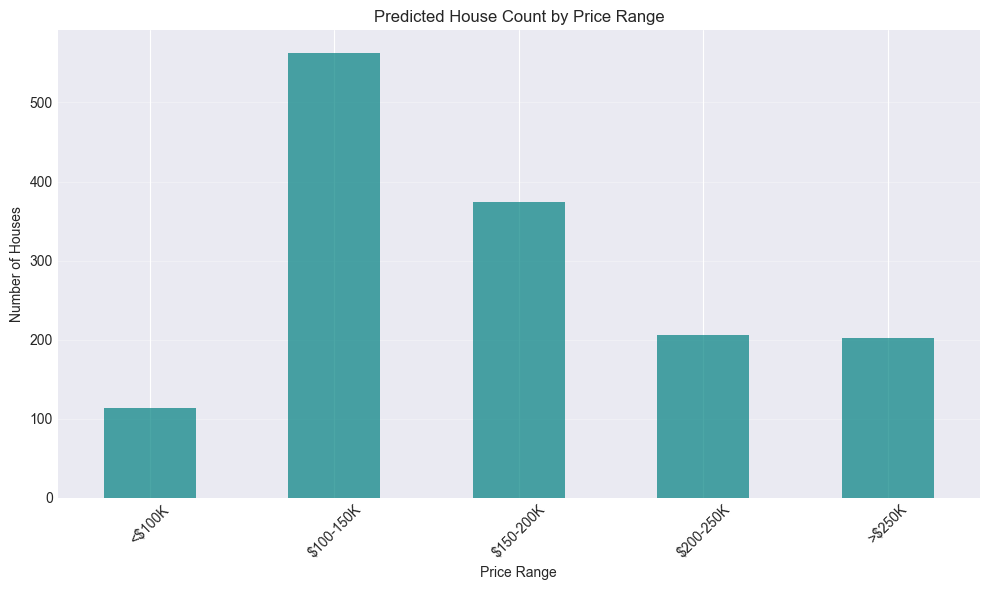

In [13]:
# Summary statistics by price range
print("\n" + "="*80)
print("PREDICTIONS BY PRICE RANGE (Ensemble)")
print("="*80)

# Create price bins
results_df['Price_Range'] = pd.cut(results_df['Ensemble_Prediction'], 
                                   bins=[0, 100000, 150000, 200000, 250000, 500000],
                                   labels=['<$100K', '$100-150K', '$150-200K', '$200-250K', '>$250K'])

price_range_summary = results_df.groupby('Price_Range').agg({
    'Id': 'count',
    'Ensemble_Prediction': ['mean', 'min', 'max'],
    'Prediction_Difference': 'mean'
}).round(0)

price_range_summary.columns = ['Count', 'Avg_Price', 'Min_Price', 'Max_Price', 'Avg_Model_Diff']
print(price_range_summary)

# Visualize
plt.figure(figsize=(10, 6))
price_range_summary['Count'].plot(kind='bar', color='teal', alpha=0.7)
plt.xlabel('Price Range')
plt.ylabel('Number of Houses')
plt.title('Predicted House Count by Price Range')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Summary and Next Steps

### What We Accomplished:

1. ✓ Loaded trained models from Notebook 1
2. ✓ Preprocessed test data using the same pipeline as training
3. ✓ Generated predictions using XGBoost, Elastic Net, and Ensemble
4. ✓ Created submission files for all three models
5. ✓ Analyzed prediction distributions and model agreement
6. ✓ Exported comprehensive results with metadata

### Files Created:

- `submission_xgboost.csv` - XGBoost predictions
- `submission_elastic_net.csv` - Elastic Net predictions
- `submission_ensemble.csv` - Ensemble predictions (recommended)
- `predictions_comprehensive_[timestamp].csv` - Full results with analysis

### Model Performance Notes:

- **XGBoost**: Typically better at capturing non-linear relationships
- **Elastic Net**: More interpretable, good for linear trends
- **Ensemble**: Combines strengths of both, usually most robust

### Recommendations:

1. **Use the Ensemble predictions** for submission (balanced performance)
2. **Review houses with large model disagreement** - may indicate uncertainty
3. **Check predictions against domain knowledge** - do they make sense?
4. **Consider outliers** - very high/low predictions may need review

### Next Steps:

- Submit `submission_ensemble.csv` for evaluation
- Use Notebook 2 to analyze individual predictions with SHAP
- Review houses with unusual predictions
- Consider retraining with different parameters if needed

---

**Notebook Complete! All predictions have been generated successfully.**